# EMNIST Balanced, Training Notebook
**Dataset:** 47 classes (digits + upper/lowercase letters), 112,800 training samples.  
**Pipeline:** Data loading → augmentation → training → loss/accuracy curves → confusion matrix.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from model import EMNISTClassifier

In [7]:
# ── Constants ─────────────────────────────────────────────────────────────────
DATA_ROOT     = './data'
ASSETS_DIR    = '../assets'   # relative to model/ directory
SAVE_PATH     = 'emnist_model.pth'
BATCH_SIZE    = 64
TEST_BATCH    = 1000
EPOCHS        = 10
LEARNING_RATE = 0.001
LOG_INTERVAL  = 1000
MEAN, STD     = 0.1751, 0.3332

os.makedirs(ASSETS_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


## 1. Data

In [8]:
def fix_emnist_orientation(tensor):
    """EMNIST images are rotated 90° and mirrored — this corrects that."""
    return tensor.transpose(1, 2)

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Lambda(fix_emnist_orientation),
    transforms.Normalize((MEAN,), (STD,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(fix_emnist_orientation),
    transforms.Normalize((MEAN,), (STD,))
])

train_dataset = datasets.EMNIST(root=DATA_ROOT, split='balanced', train=True,  download=True, transform=train_transform)
test_dataset  = datasets.EMNIST(root=DATA_ROOT, split='balanced', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=TEST_BATCH, shuffle=False)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')
print(f'Classes       : {train_dataset.classes}')

Train samples : 112,800
Test samples  : 18,800
Classes       : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']


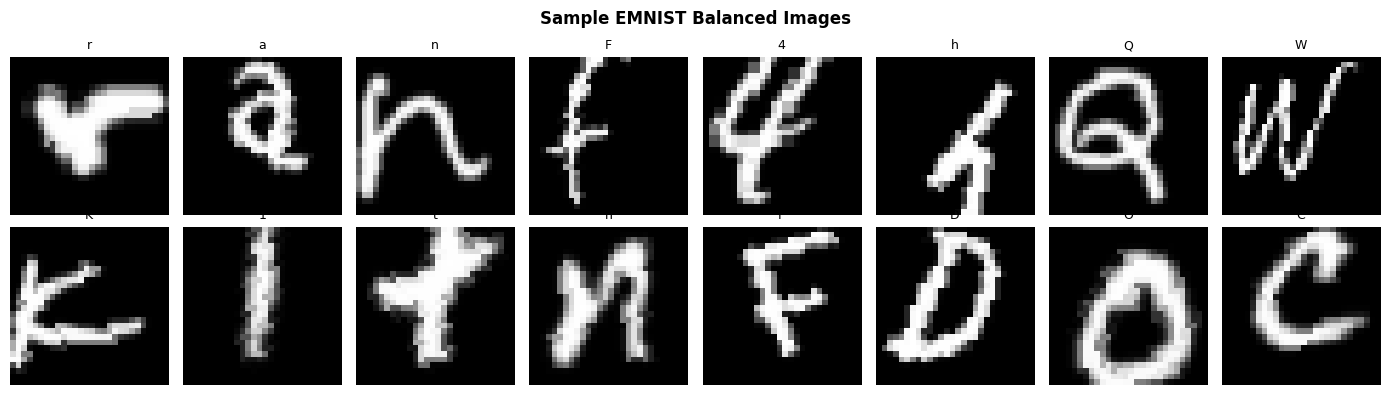

In [9]:
# Sample images from the dataset
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(train_dataset.classes[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample EMNIST Balanced Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Model

In [10]:
model     = EMNISTClassifier().to(device)
loss_fn   = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model        : EMNISTClassifier')
print(f'Parameters   : {total_params:,}')
print(f'Loss         : CrossEntropyLoss')
print(f'Optimizer    : Adam (lr={LEARNING_RATE})')

Model        : EMNISTClassifier
Parameters   : 239,919
Loss         : CrossEntropyLoss
Optimizer    : Adam (lr=0.001)


## 3. Training

In [11]:
def train_one_epoch(model, loss_fn, optimizer, loader, device):
    """Runs one full training epoch. Returns (avg_loss, accuracy %)."""
    model.train()
    total_loss, interval_loss = 0.0, 0.0
    correct, count = 0, 0

    for i, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted   = outputs.max(1)
        total_loss    += loss.item()
        interval_loss += loss.item()
        count   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (i + 1) % LOG_INTERVAL == 0:
            print(f'  Step [{i+1:>4}]  Loss: {interval_loss / LOG_INTERVAL:.4f}  |  Acc: {100 * correct / count:.2f}%')
            interval_loss = 0.0

    return total_loss / len(loader), 100 * correct / count


def evaluate(model, loader, device, return_preds=False):
    """Evaluates model. If return_preds=True, also returns (all_labels, all_preds)."""
    model.eval()
    correct, count = 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, predicted   = model(inputs).max(1)
            count   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            if return_preds:
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / count
    return (accuracy, np.array(all_labels), np.array(all_preds)) if return_preds else accuracy

In [12]:
train_losses, train_accs, test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    print(f'Epoch {epoch}/{EPOCHS}')
    train_loss, train_acc = train_one_epoch(model, loss_fn, optimizer, train_loader, device)
    test_acc              = evaluate(model, test_loader, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'  → Loss: {train_loss:.4f}  |  Train Acc: {train_acc:.2f}%  |  Test Acc: {test_acc:.2f}%\n')

Epoch 1/10
  Step [1000]  Loss: 1.6822  |  Acc: 51.72%
  → Loss: 1.3940  |  Train Acc: 58.95%  |  Test Acc: 78.69%

Epoch 2/10
  Step [1000]  Loss: 0.8864  |  Acc: 71.95%
  → Loss: 0.8551  |  Train Acc: 72.65%  |  Test Acc: 81.06%

Epoch 3/10
  Step [1000]  Loss: 0.7644  |  Acc: 75.15%
  → Loss: 0.7547  |  Train Acc: 75.50%  |  Test Acc: 82.51%

Epoch 4/10
  Step [1000]  Loss: 0.7137  |  Acc: 76.39%
  → Loss: 0.7083  |  Train Acc: 76.56%  |  Test Acc: 82.38%

Epoch 5/10
  Step [1000]  Loss: 0.6844  |  Acc: 77.26%
  → Loss: 0.6775  |  Train Acc: 77.46%  |  Test Acc: 83.02%

Epoch 6/10
  Step [1000]  Loss: 0.6615  |  Acc: 78.21%
  → Loss: 0.6597  |  Train Acc: 78.20%  |  Test Acc: 83.74%

Epoch 7/10
  Step [1000]  Loss: 0.6426  |  Acc: 78.50%
  → Loss: 0.6389  |  Train Acc: 78.67%  |  Test Acc: 83.10%

Epoch 8/10
  Step [1000]  Loss: 0.6327  |  Acc: 78.71%
  → Loss: 0.6334  |  Train Acc: 78.63%  |  Test Acc: 84.21%

Epoch 9/10
  Step [1000]  Loss: 0.6214  |  Acc: 79.11%
  → Loss: 0.6192 

## 4. Results

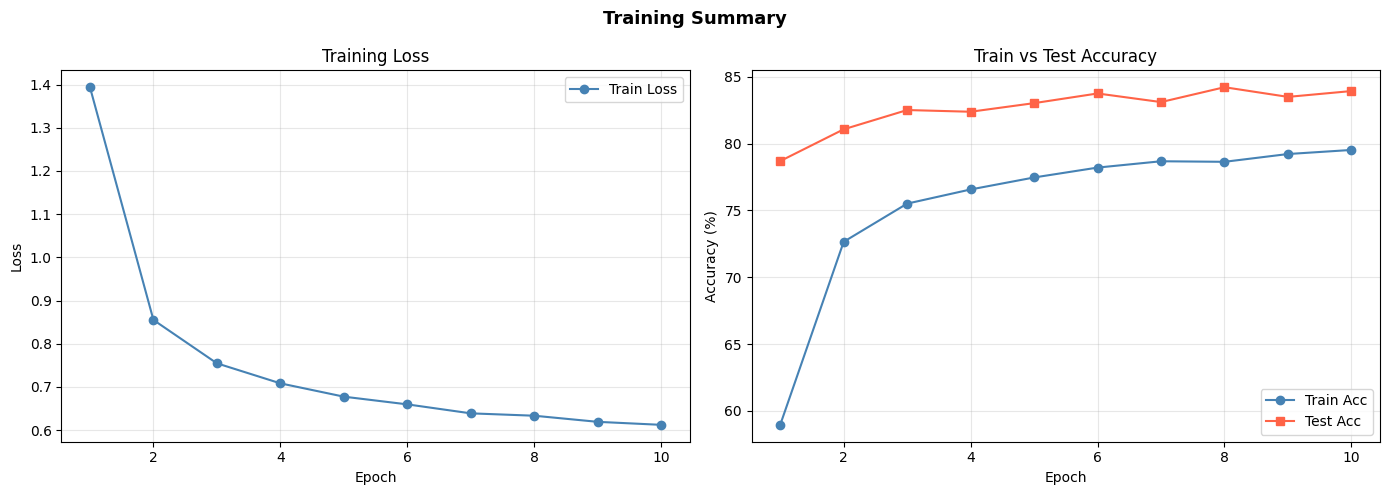

Best Test Accuracy: 84.21%  (Epoch 8)


In [13]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs_range, train_losses, marker='o', color='steelblue', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, train_accs, marker='o', color='steelblue', label='Train Acc')
ax2.plot(epochs_range, test_accs,  marker='s', color='tomato',    label='Test Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train vs Test Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best Test Accuracy: {max(test_accs):.2f}%  (Epoch {test_accs.index(max(test_accs)) + 1})')

Final Test Accuracy: 83.93%


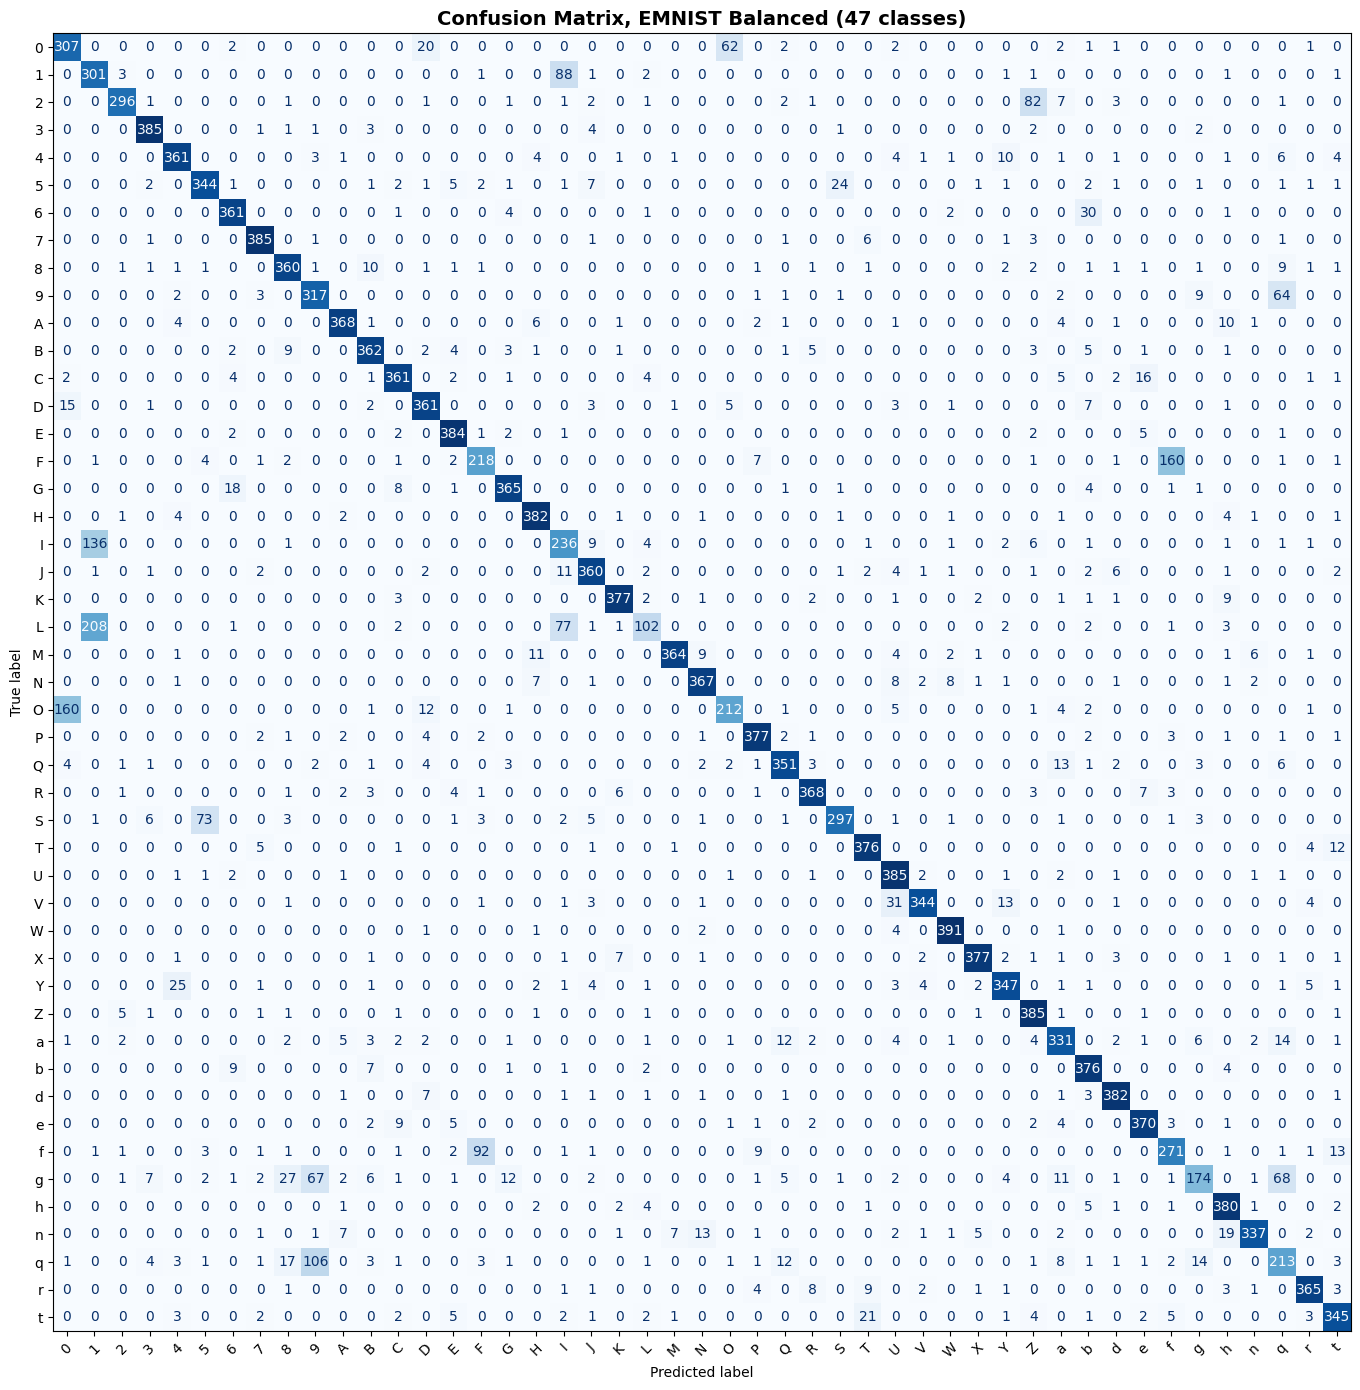

In [15]:
final_acc, all_labels, all_preds = evaluate(model, test_loader, device, return_preds=True)
print(f'Final Test Accuracy: {final_acc:.2f}%')

fig, ax = plt.subplots(figsize=(16, 14))
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=test_dataset.classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix, EMNIST Balanced (47 classes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ASSETS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
torch.save(model.state_dict(), SAVE_PATH)
print(f'Model saved → {SAVE_PATH}')

Model saved → emnist_model.pth
